In [1]:
library(miloR)
library(patchwork)

here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))

Loading required package: edgeR

Loading required package: limma

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/06_Runx1_RNA/code



In [2]:
args = list()
args$samples <- opts$samples
args$sce <- io$rna.sce
args$metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/06_Runx1_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz"

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & sample%in%args$samples]


In [3]:

###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame


Loading required package: scuttle


Attaching package: ‘scater’


The following object is masked from ‘package:limma’:

    plotMDS




In [4]:
pca = as.data.frame(fread("/rds/project/rds-SDzz0CATGms/users/bt392/06_Runx1_RNA/results/rna/dimensionality_reduction/test/pca_features1000_pcs30_batchcorrectionbysample.txt.gz"))

In [5]:
rownames(pca) = pca[,1]
pca = pca[,-1]

In [6]:
reducedDims(sce) <- list(pca.corrected=pca)

In [7]:
embryo_data = sce

In [8]:
nrow(colData(sce))

[1] 34893

In [9]:
# colnames(embryo_data) = paste0('cell_', 1:nrow(colData(embryo_data)))
# rownames(reducedDim(embryo_data, "pca.corrected")) = paste0('cell_', 1:nrow(colData(embryo_data)))

In [10]:
embryo_data
class(reducedDim(embryo_data, "pca.corrected"))
head(reducedDim(embryo_data, "pca.corrected"))

class: SingleCellExperiment 
dim: 29453 34893 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(34893): SLX-21184_SITTA7_H5NKNDMXY#AAACGAACAATTGCAC-1
  SLX-21184_SITTA7_H5NKNDMXY#AAACGAACACCAGCTG-1 ...
  SLX-21184_SITTH10_H5NKNDMXY#TTTGTTGAGGATTTAG-1
  SLX-21184_SITTH10_H5NKNDMXY#TTTGTTGCAAGTACCT-1
colData names(13): barcode sample ... celltype.score_mnn
  closest.cell_mnn
reducedDimNames(1): pca.corrected
mainExpName: RNA
altExpNames(0):

[1] "data.frame"

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SLX-21184_SITTA7_H5NKNDMXY#AAACGAACAATTGCAC-1,13.781,12.869,2.216,-0.767,-1.200,0.184,1.330,1.161,0.971,-1.404,⋯,-0.551,3.237,1.213,-1.057,-0.483,1.244,0.207,0.878,2.037,-0.749
SLX-21184_SITTA7_H5NKNDMXY#AAACGAACACCAGCTG-1,13.231,9.648,2.726,0.072,-2.791,0.673,1.486,-0.199,0.412,-0.545,⋯,0.727,-0.070,-1.502,-1.211,-1.657,1.185,1.193,0.674,1.662,-0.791
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACAGACAGTCG-1,-0.494,-5.019,1.367,1.179,11.746,-2.427,-3.173,-9.063,6.742,-1.450,⋯,0.838,-2.998,3.425,4.103,0.653,-0.991,4.074,-1.702,-0.846,3.168
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACCAAATGATG-1,13.657,11.462,2.762,-0.158,-1.450,-0.574,1.705,1.739,-0.044,-1.269,⋯,-0.254,1.439,0.608,-0.338,-0.539,0.718,-0.467,1.006,1.199,-0.576
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACCACTTTATC-1,1.452,1.399,-0.241,12.538,-1.719,-3.949,-8.193,-8.003,-2.412,-0.159,⋯,1.360,-3.723,0.966,1.569,1.582,-1.360,-2.086,-2.899,-1.990,0.443
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACGTATGGGAC-1,14.401,10.599,1.989,-0.413,-1.343,-0.168,1.667,1.011,0.596,-1.594,⋯,0.818,0.589,0.052,-1.830,-1.487,0.707,1.323,0.763,1.797,-0.647


In [11]:
reducedDim(embryo_data, "pca.corrected") = as.matrix(reducedDim(embryo_data, "pca.corrected"))

In [12]:
head(reducedDim(embryo_data, "pca.corrected"))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
SLX-21184_SITTA7_H5NKNDMXY#AAACGAACAATTGCAC-1,13.781,12.869,2.216,-0.767,-1.200,0.184,1.330,1.161,0.971,-1.404,⋯,-0.551,3.237,1.213,-1.057,-0.483,1.244,0.207,0.878,2.037,-0.749
SLX-21184_SITTA7_H5NKNDMXY#AAACGAACACCAGCTG-1,13.231,9.648,2.726,0.072,-2.791,0.673,1.486,-0.199,0.412,-0.545,⋯,0.727,-0.070,-1.502,-1.211,-1.657,1.185,1.193,0.674,1.662,-0.791
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACAGACAGTCG-1,-0.494,-5.019,1.367,1.179,11.746,-2.427,-3.173,-9.063,6.742,-1.450,⋯,0.838,-2.998,3.425,4.103,0.653,-0.991,4.074,-1.702,-0.846,3.168
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACCAAATGATG-1,13.657,11.462,2.762,-0.158,-1.450,-0.574,1.705,1.739,-0.044,-1.269,⋯,-0.254,1.439,0.608,-0.338,-0.539,0.718,-0.467,1.006,1.199,-0.576
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACCACTTTATC-1,1.452,1.399,-0.241,12.538,-1.719,-3.949,-8.193,-8.003,-2.412,-0.159,⋯,1.360,-3.723,0.966,1.569,1.582,-1.360,-2.086,-2.899,-1.990,0.443
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACGTATGGGAC-1,14.401,10.599,1.989,-0.413,-1.343,-0.168,1.667,1.011,0.596,-1.594,⋯,0.818,0.589,0.052,-1.830,-1.487,0.707,1.323,0.763,1.797,-0.647


In [13]:
embryo_data <- embryo_data[,apply(reducedDim(embryo_data, "pca.corrected"), 1, function(x) !all(is.na(x)))]
embryo_data <- runUMAP(embryo_data, dimred = "pca.corrected", name = 'umap')

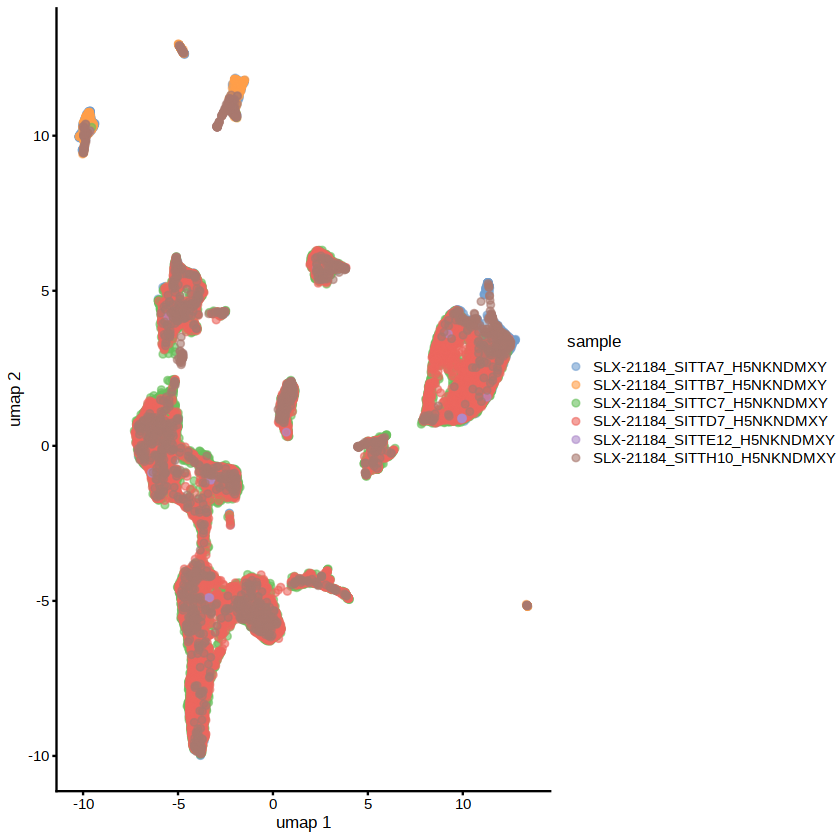

In [14]:
plotReducedDim(embryo_data, colour_by="sample", dimred = "umap") 

In [15]:
embryo_milo <- Milo(embryo_data)
embryo_milo

class: Milo 
dim: 29453 34893 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(34893): SLX-21184_SITTA7_H5NKNDMXY#AAACGAACAATTGCAC-1
  SLX-21184_SITTA7_H5NKNDMXY#AAACGAACACCAGCTG-1 ...
  SLX-21184_SITTH10_H5NKNDMXY#TTTGTTGAGGATTTAG-1
  SLX-21184_SITTH10_H5NKNDMXY#TTTGTTGCAAGTACCT-1
colData names(13): barcode sample ... celltype.score_mnn
  closest.cell_mnn
reducedDimNames(2): pca.corrected umap
mainExpName: RNA
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [21]:
# try different settings
milo_graph = function(prop=0.01, k=30, d=30) {
            embryo_milo <- buildGraph(embryo_milo, k = k, d = d, reduced.dim = "pca.corrected")
            embryo_milo <- makeNhoods(embryo_milo, prop = prop, k = k, d = d, refined = TRUE, reduced_dims = "pca.corrected")

            colData(embryo_milo)$doublet = ifelse(colData(embryo_milo)$doublet_score > 0.8, TRUE, FALSE)
            colData(embryo_milo)$sample_doublet = paste0(colData(embryo_milo)$sample, '_', colData(embryo_milo)$doublet)
            embryo_milo <- countCells(embryo_milo, meta.data = as.data.frame(colData(embryo_milo)), sample="sample_doublet")

            embryo_design <- data.frame(colData(embryo_milo))[,c("sample", "doublet", "sample_doublet")]

            ## Convert batch info from integer to factor
            embryo_design$doublet <- as.factor(embryo_design$doublet) 

            embryo_design <- distinct(embryo_design)
            rownames(embryo_design) <- embryo_design$sample_doublet

            embryo_milo <- calcNhoodDistance(embryo_milo, d=d, reduced.dim = "pca.corrected")

            #embryo_design$exp = c('A', 'B', 'A', 'A', 'A', 'A')
            embryo_design$stage = embryo_design$sample
            # design = what to test for, can correct for another variable as well
            da_results <- testNhoods(embryo_milo, design = ~ doublet, design.df = embryo_design, reduced.dim="pca.corrected")
            head(da_results)

            embryo_milo <- buildNhoodGraph(embryo_milo)

            ## Plot single-cell UMAP
            umap_pl <- plotReducedDim(embryo_milo, dimred = "umap", colour_by="sample", text_by = "celltype.mapped_mnn", 
                              text_size = 3, point_size=0.5) +
            guides(fill="none")

            ## Plot neighbourhood graph
            nh_graph_pl <- plotNhoodGraphDA(embryo_milo, da_results, layout="umap",alpha=0.1) 

            umap_pl + nh_graph_pl +
            plot_layout(guides="collect")
}

In [22]:
milo_graph(0.005, 10, 10)

Warning message in (function (to_check, X, clust_centers, clust_info, dtype, nn, :
“detected tied distances to neighbors, see ?'BiocNeighbors-ties'”
Constructing kNN graph with k:10

Checking valid object

Checking meta.data validity

Counting cells in neighbourhoods

Using TMM normalisation

Warning message in DGEList(counts = nhoodCounts(x)[keep.nh, keep.samps], lib.size = colSums(nhoodCounts(x)[keep.nh, :
“library size of zero detected”


ERROR: Error in if (median(f75) < 1e-20) {: missing value where TRUE/FALSE needed


In [17]:
embryo_milo <- buildGraph(embryo_milo, k = 30, d = 30, reduced.dim = "pca.corrected")

Constructing kNN graph with k:30



In [18]:
# lower prop for larger datasets
embryo_milo <- makeNhoods(embryo_milo, prop = 0.01, k = 30, d=30, refined = TRUE, reduced_dims = "pca.corrected")

Checking valid object

Warning message in (function (to_check, X, clust_centers, clust_info, dtype, nn, :
“detected tied distances to neighbors, see ?'BiocNeighbors-ties'”


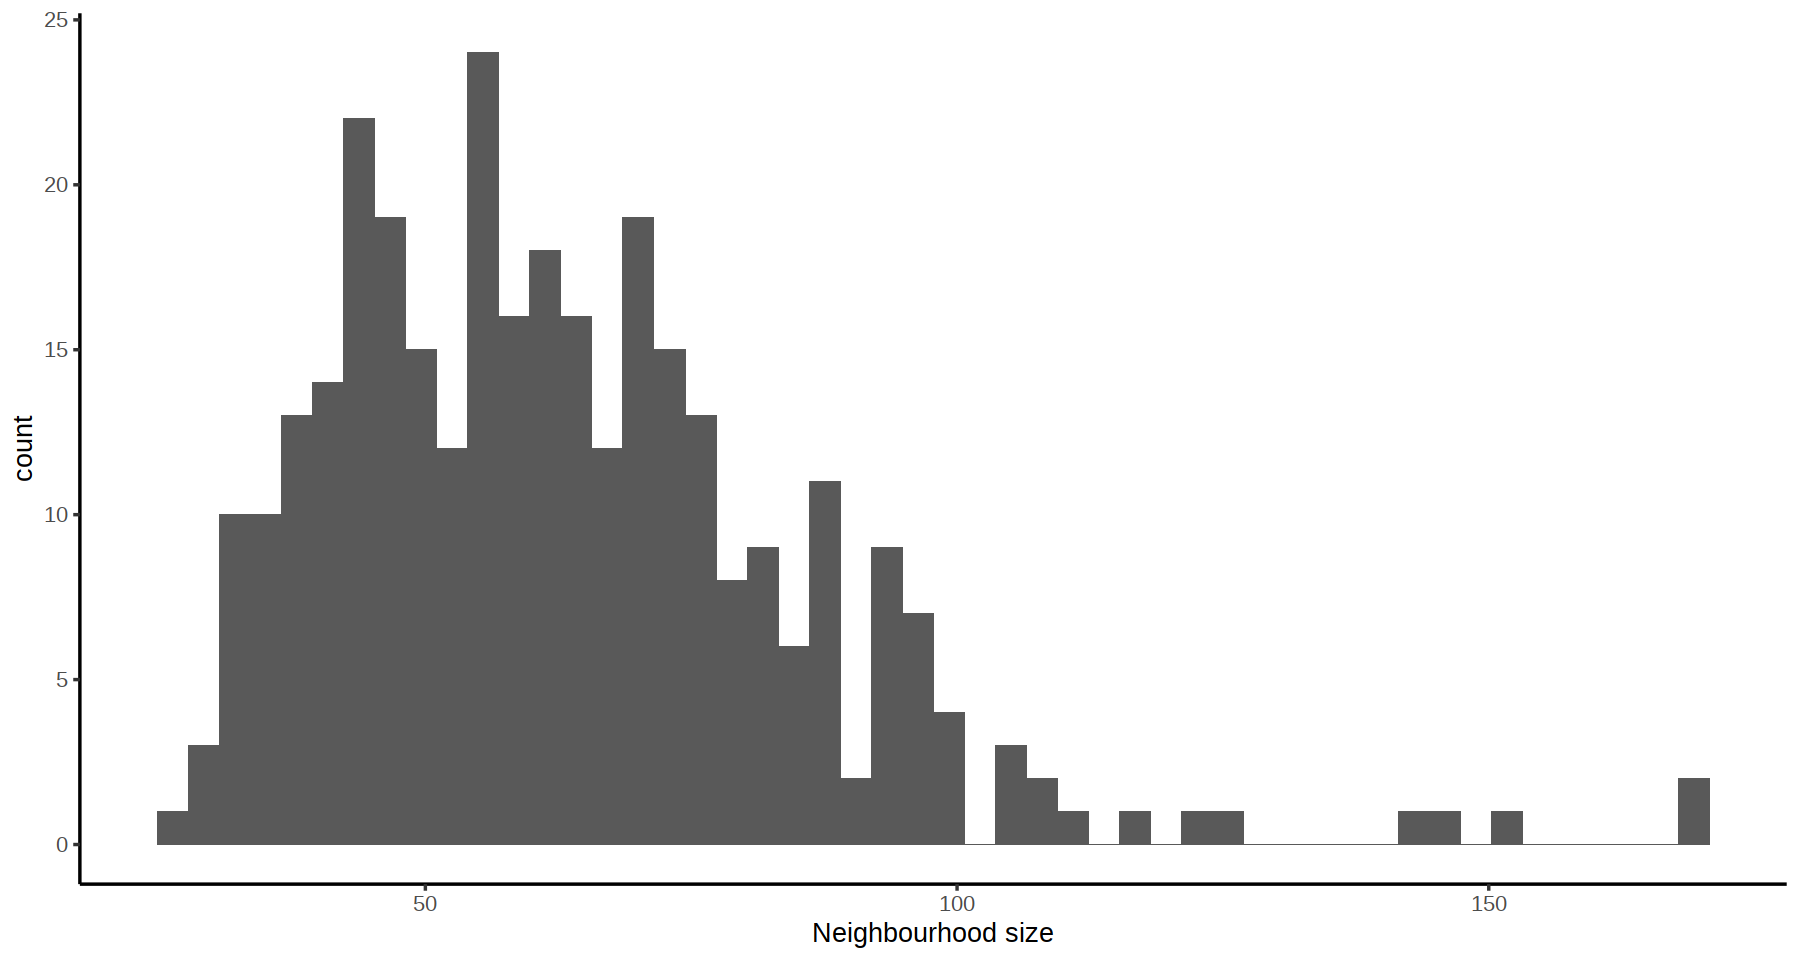

In [229]:
plotNhoodSizeHist(embryo_milo)

In [230]:
colData(embryo_milo)$doublet = ifelse(colData(embryo_milo)$doublet_score > 0.8, TRUE, FALSE)
colData(embryo_milo)$sample_doublet = paste0(colData(embryo_milo)$sample, '_', colData(embryo_milo)$doublet)

In [231]:
embryo_milo <- countCells(embryo_milo, meta.data = as.data.frame(colData(embryo_milo)), sample="sample_doublet")

Checking meta.data validity

Counting cells in neighbourhoods



In [232]:
head(nhoodCounts(embryo_milo))

   [[ suppressing 12 column names ‘SLX-21184_SITTA7_H5NKNDMXY_FALSE’, ‘SLX-21184_SITTA7_H5NKNDMXY_TRUE’, ‘SLX-21184_SITTB7_H5NKNDMXY_FALSE’ ... ]]



6 x 12 sparse Matrix of class "dgCMatrix"
                            
1 . 1 . . 49 1 83 3 . .  6 1
2 1 . . . 23 . 14 . . . 11 .
3 . . . . 20 . 46 3 1 .  . .
4 . . . . 20 . 32 1 . .  . .
5 . . . . 14 . 22 . . .  . .
6 . . . 1 39 1 34 2 . .  . .

In [233]:
embryo_design <- data.frame(colData(embryo_milo))[,c("sample", "doublet", "sample_doublet")]

## Convert batch info from integer to factor
embryo_design$doublet <- as.factor(embryo_design$doublet) 

embryo_design <- distinct(embryo_design)
rownames(embryo_design) <- embryo_design$sample_doublet

embryo_design

,sample,doublet,sample_doublet
,<chr>,<fct>,<chr>
SLX-21184_SITTA7_H5NKNDMXY_FALSE,SLX-21184_SITTA7_H5NKNDMXY,FALSE,SLX-21184_SITTA7_H5NKNDMXY_FALSE
SLX-21184_SITTA7_H5NKNDMXY_TRUE,SLX-21184_SITTA7_H5NKNDMXY,TRUE,SLX-21184_SITTA7_H5NKNDMXY_TRUE
SLX-21184_SITTB7_H5NKNDMXY_FALSE,SLX-21184_SITTB7_H5NKNDMXY,FALSE,SLX-21184_SITTB7_H5NKNDMXY_FALSE
SLX-21184_SITTB7_H5NKNDMXY_TRUE,SLX-21184_SITTB7_H5NKNDMXY,TRUE,SLX-21184_SITTB7_H5NKNDMXY_TRUE
SLX-21184_SITTC7_H5NKNDMXY_FALSE,SLX-21184_SITTC7_H5NKNDMXY,FALSE,SLX-21184_SITTC7_H5NKNDMXY_FALSE
SLX-21184_SITTC7_H5NKNDMXY_TRUE,SLX-21184_SITTC7_H5NKNDMXY,TRUE,SLX-21184_SITTC7_H5NKNDMXY_TRUE
SLX-21184_SITTD7_H5NKNDMXY_FALSE,SLX-21184_SITTD7_H5NKNDMXY,FALSE,SLX-21184_SITTD7_H5NKNDMXY_FALSE
SLX-21184_SITTD7_H5NKNDMXY_TRUE,SLX-21184_SITTD7_H5NKNDMXY,TRUE,SLX-21184_SITTD7_H5NKNDMXY_TRUE
SLX-21184_SITTE12_H5NKNDMXY_FALSE,SLX-21184_SITTE12_H5NKNDMXY,FALSE,SLX-21184_SITTE12_H5NKNDMXY_FALSE


In [234]:
embryo_milo <- calcNhoodDistance(embryo_milo, d=30, reduced.dim = "pca.corrected")

In [237]:
#embryo_design$exp = c('A', 'B', 'A', 'A', 'A', 'A')
embryo_design$stage = embryo_design$sample
# design = what to test for, can correct for another variable as well
da_results <- testNhoods(embryo_milo, design = ~ doublet, design.df = embryo_design, reduced.dim="pca.corrected")
head(da_results)

Using TMM normalisation

Warning message in DGEList(counts = nhoodCounts(x)[keep.nh, keep.samps], lib.size = colSums(nhoodCounts(x)[keep.nh, :
“library size of zero detected”


ERROR: Error in if (median(f75) < 1e-20) {: missing value where TRUE/FALSE needed


In [193]:
da_results %>%
  arrange(SpatialFDR) %>%
  head() 

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-6.139378,8.990325,2.109145,0.1464544,0.2639633,1,0.2641273
2,-6.507461,9.413328,2.311151,0.1284826,0.2639633,2,0.2641273
3,-6.795853,9.657094,2.435457,0.1186530,0.2639633,3,0.2641273
4,-6.490345,9.170301,2.441926,0.1181648,0.2639633,4,0.2641273
5,-5.824109,8.803501,1.863777,0.1722222,0.2639633,5,0.2641273
6,-6.621982,9.359018,2.507049,0.1133716,0.2639633,6,0.2641273


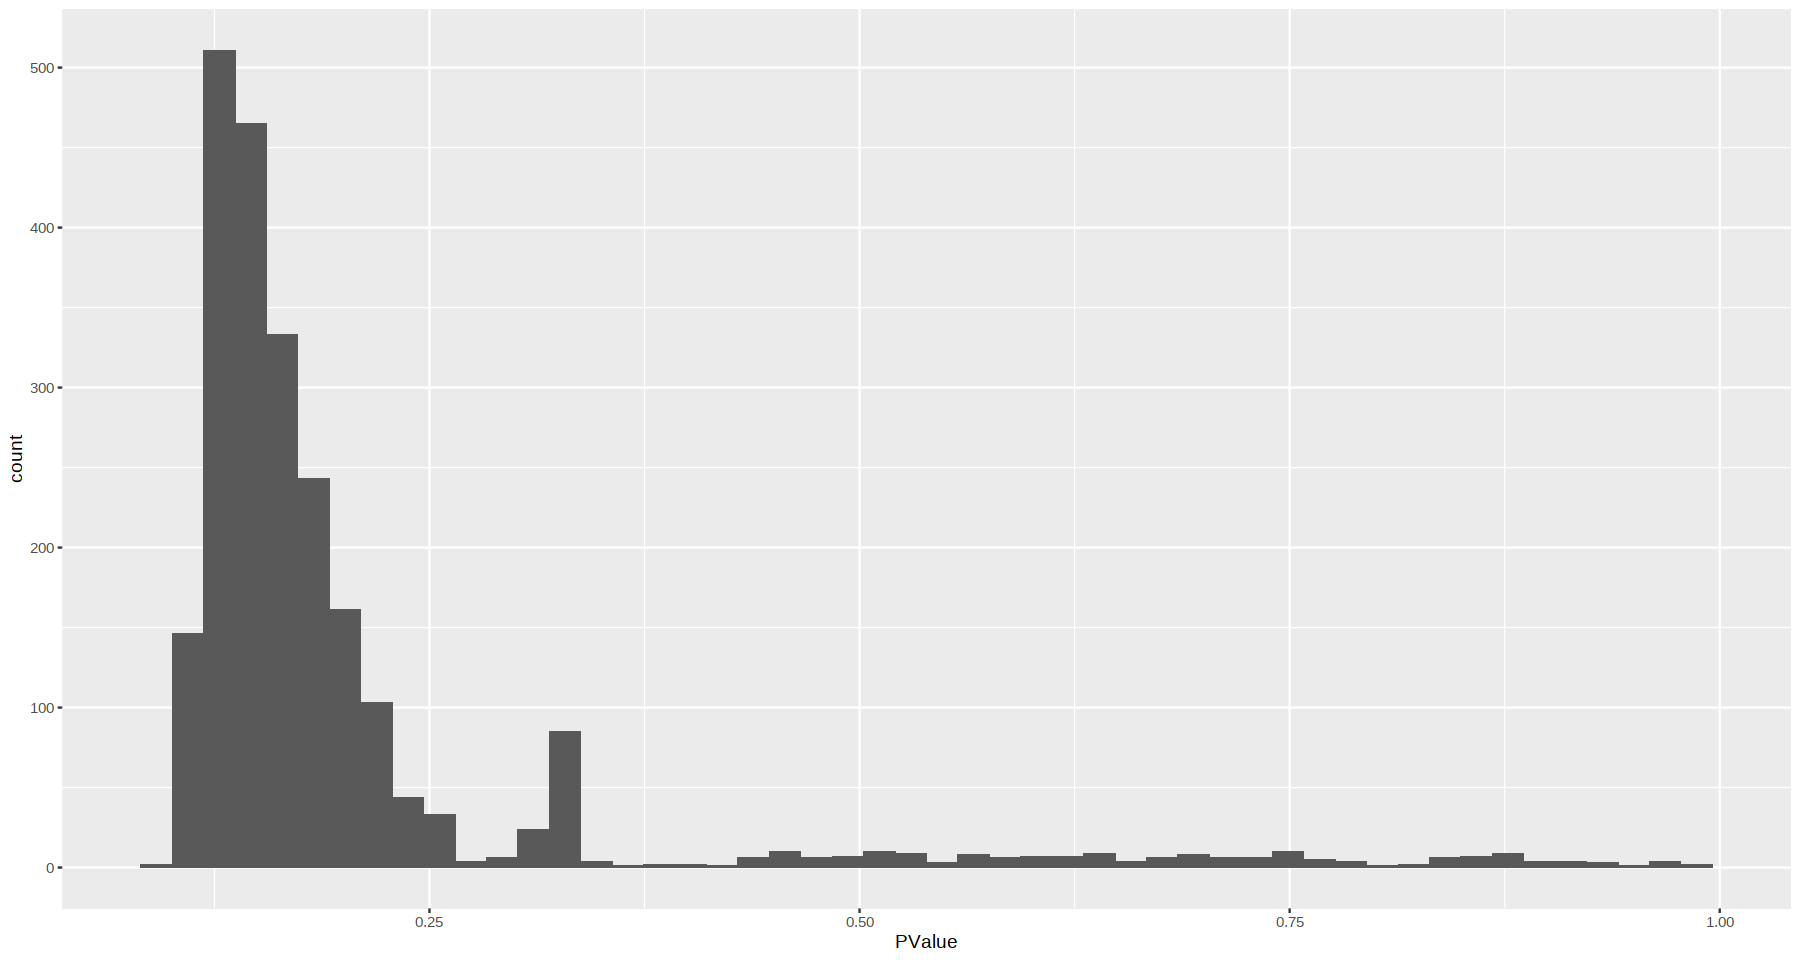

In [194]:
ggplot(da_results, aes(PValue)) + geom_histogram(bins=50)

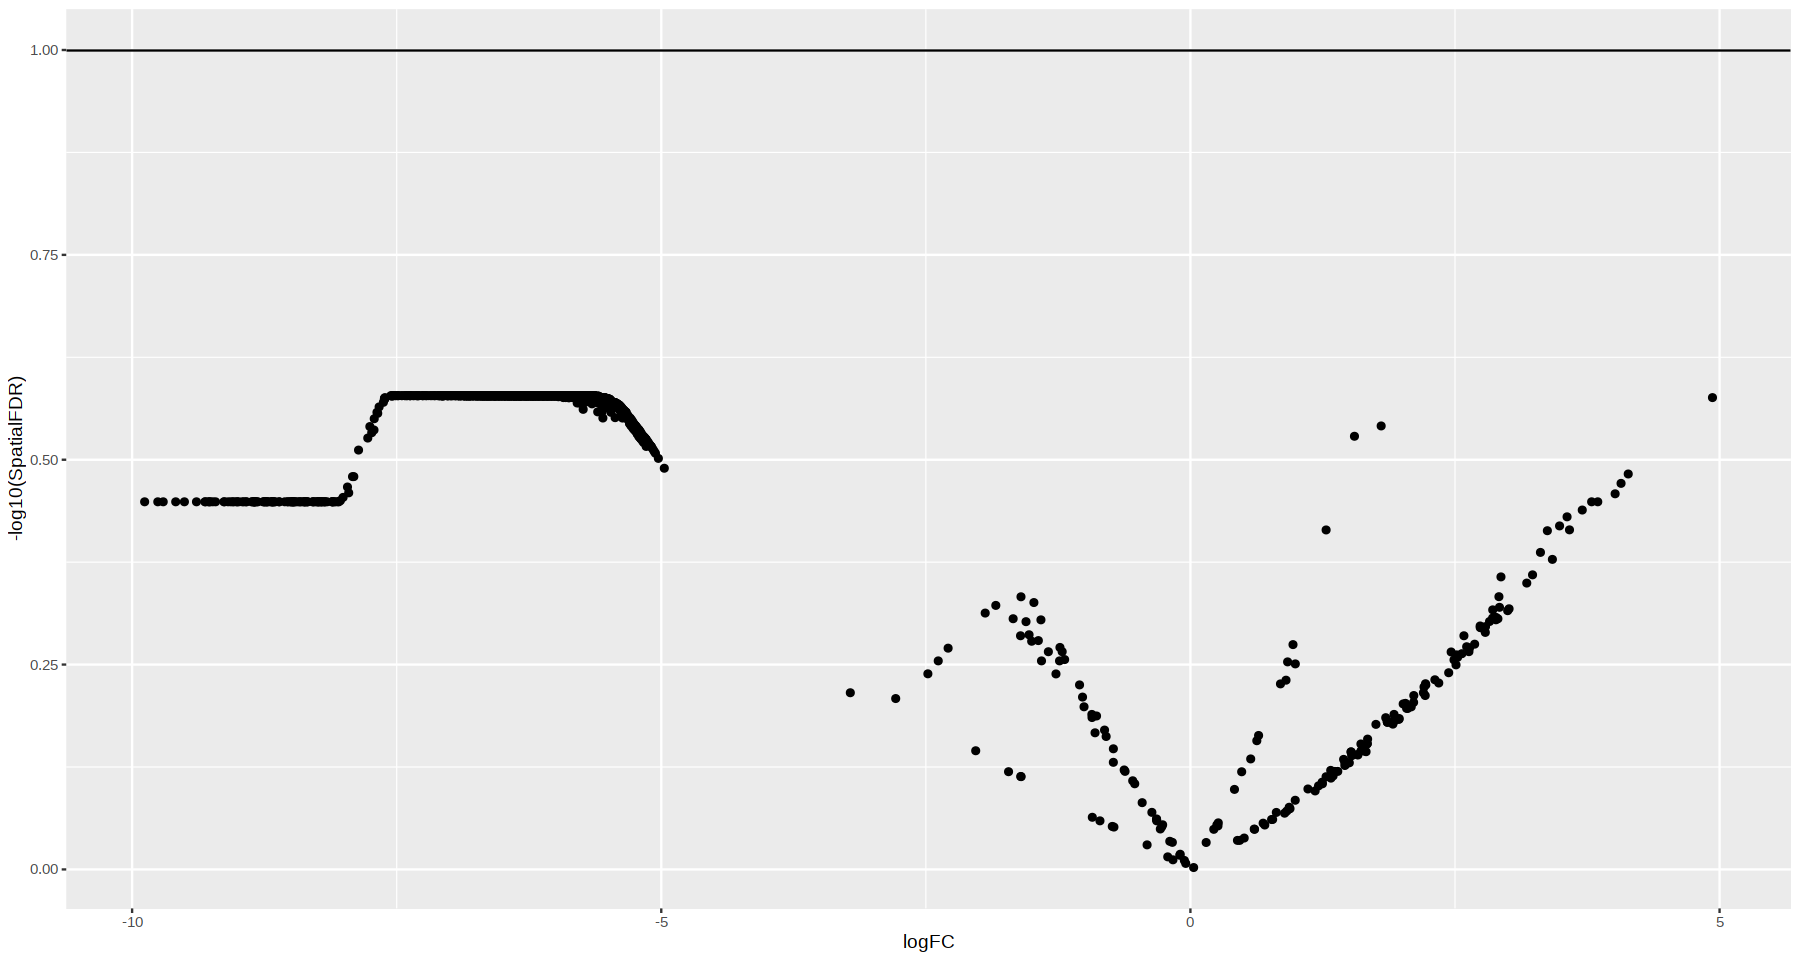

In [195]:
ggplot(da_results, aes(logFC, -log10(SpatialFDR))) + 
  geom_point() +
  geom_hline(yintercept = 1) ## Mark significance threshold (10% FDR)

In [196]:
options(repr.plot.width=15, repr.plot.height=8)

Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


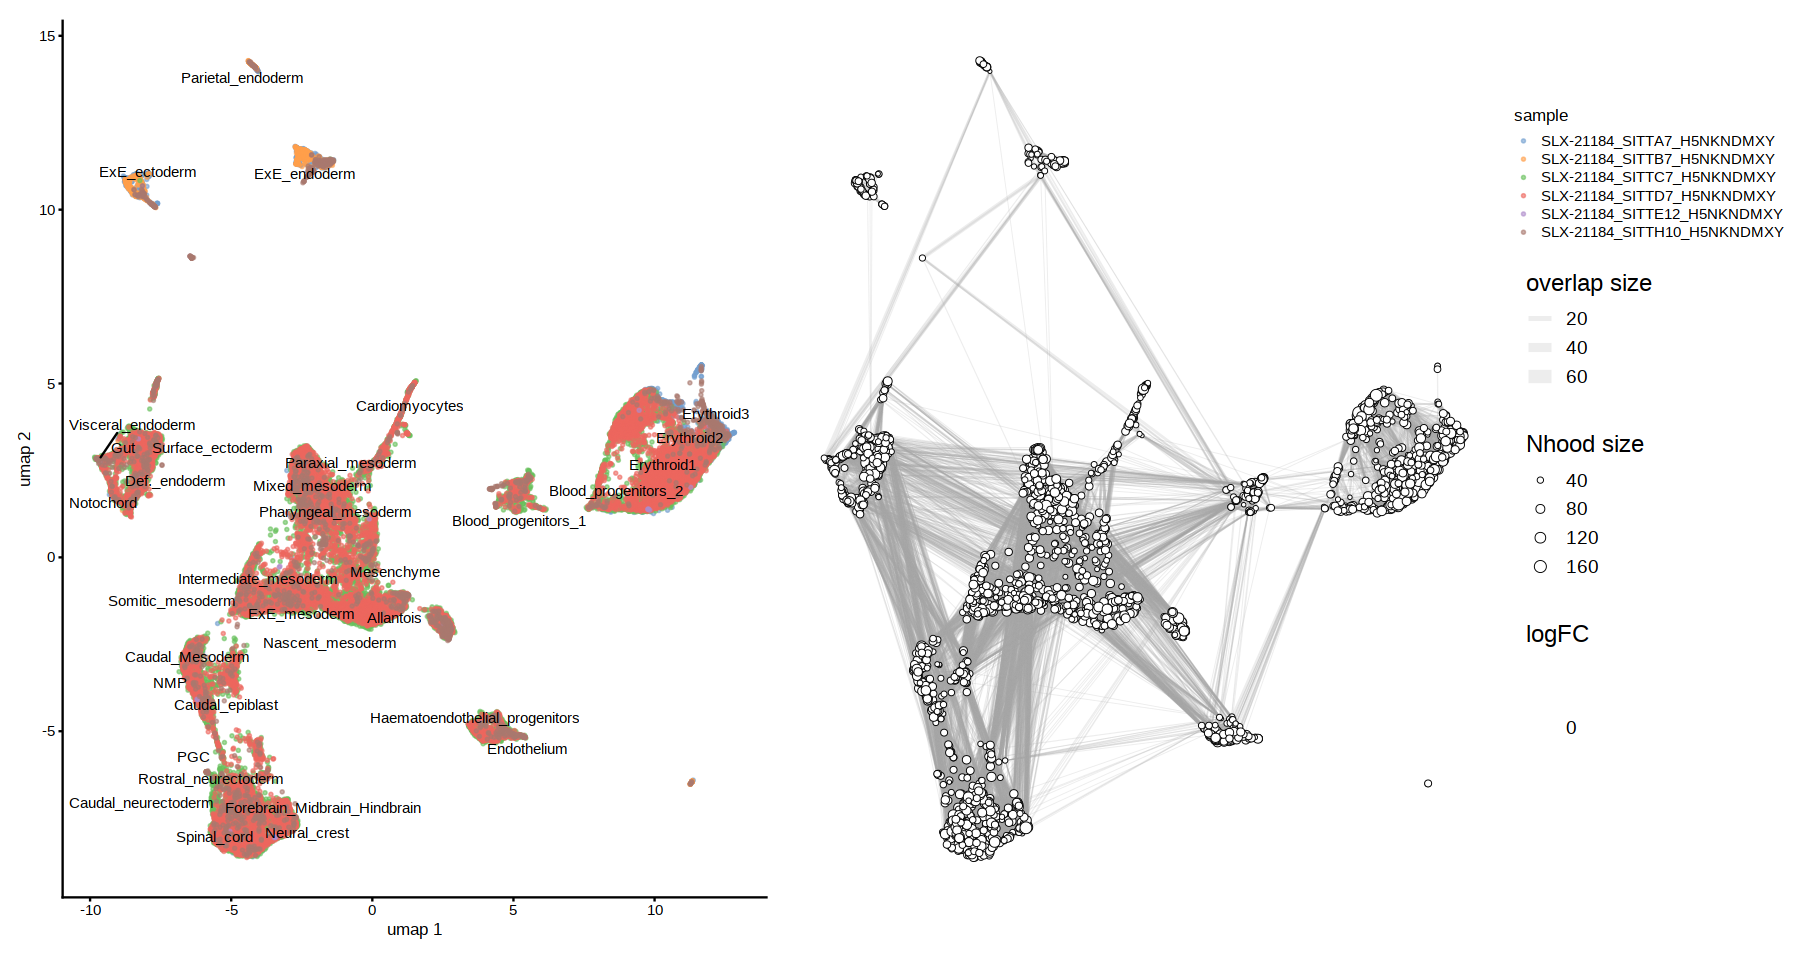

In [197]:
embryo_milo <- buildNhoodGraph(embryo_milo)

## Plot single-cell UMAP
umap_pl <- plotReducedDim(embryo_milo, dimred = "umap", colour_by="sample", text_by = "celltype.mapped_mnn", 
                          text_size = 3, point_size=0.5) +
  guides(fill="none")

## Plot neighbourhood graph
nh_graph_pl <- plotNhoodGraphDA(embryo_milo, da_results, layout="umap",alpha=0.1) 
  
umap_pl + nh_graph_pl +
  plot_layout(guides="collect")

In [17]:
da_results <- annotateNhoods(embryo_milo, da_results, coldata_col = "celltype.mapped_mnn")
head(da_results)

Converting celltype to factor...



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype,celltype_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,2.3818445,11.45215,4.60566154,3.204127e-02,4.764579e-02,1,4.898467e-02,ExE ectoderm,1.0000000
2,0.2015533,10.94925,0.03796758,8.455371e-01,8.663445e-01,2,8.671780e-01,Epiblast,0.7777778
3,-4.5016327,11.88769,19.85316159,9.041502e-06,3.834267e-05,3,3.415460e-05,Epiblast,0.6279070
4,-5.9194372,11.90241,33.01688377,1.123683e-08,2.573235e-07,4,2.134813e-07,Epiblast,1.0000000
5,2.2014830,11.41027,3.75325250,5.290959e-02,7.433311e-02,5,7.619519e-02,ExE endoderm,1.0000000
6,-1.4992818,12.27363,2.55217905,1.103722e-01,1.452599e-01,6,1.477258e-01,ExE ectoderm,1.0000000


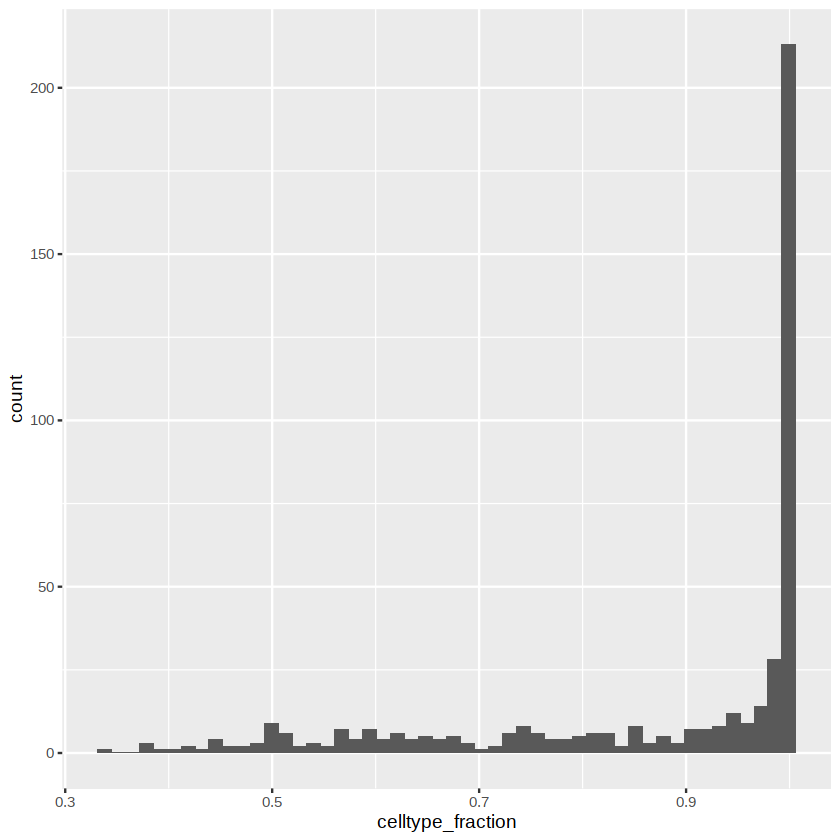

In [18]:
ggplot(da_results, aes(celltype_fraction)) + geom_histogram(bins=50)

In [19]:
da_results$celltype <- ifelse(da_results$celltype_fraction < 0.7, "Mixed", da_results$celltype.mapped_mnn)


Converting group.by to factor...



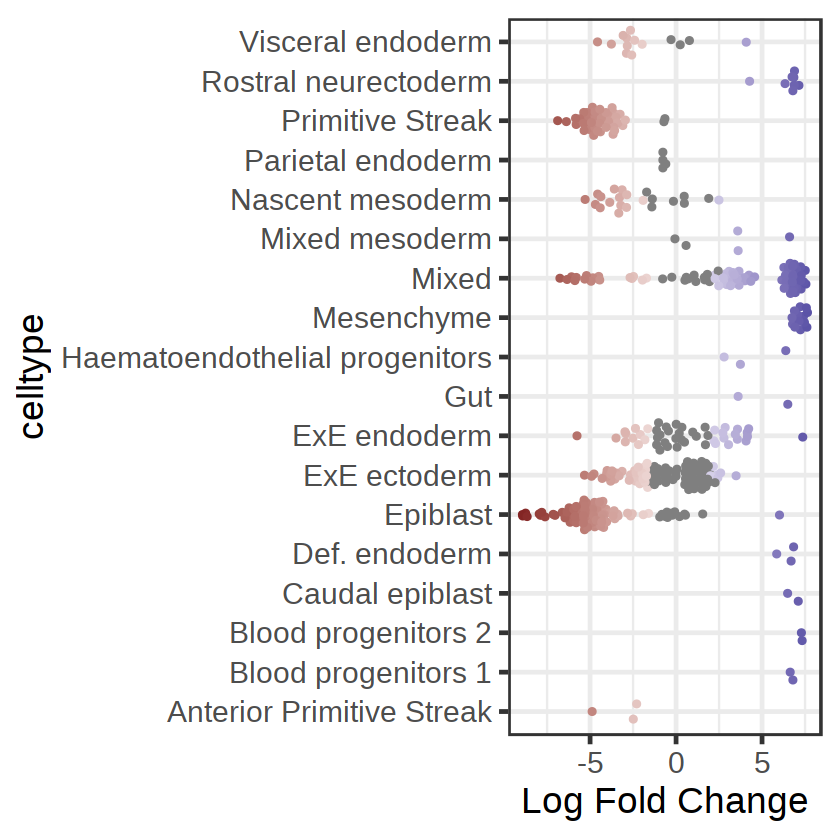

In [20]:
plotDAbeeswarm(da_results, group.by = "celltype")


In [21]:
## Add log normalized count to Milo object
embryo_milo <- logNormCounts(embryo_milo)

da_results$NhoodGroup <- as.numeric(da_results$SpatialFDR < 0.1 & da_results$logFC < 0)
da_nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = rownames(embryo_milo)[1:10])

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


In [22]:
head(da_nhood_markers)

,logFC_0,adj.P.Val_0,logFC_1,adj.P.Val_1,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000025902,0.0852569296,0.003539327,-0.0852569296,0.003539327,ENSMUSG00000025902
ENSMUSG00000033845,-0.0675290142,0.014585661,0.0675290142,0.014585661,ENSMUSG00000033845
ENSMUSG00000025903,-0.0525990165,0.030271461,0.0525990165,0.030271461,ENSMUSG00000025903
ENSMUSG00000104217,0.0013355485,0.258161240,-0.0013355485,0.258161240,ENSMUSG00000104217
ENSMUSG00000033813,-0.0315940518,0.258161240,0.0315940518,0.258161240,ENSMUSG00000033813
ENSMUSG00000102343,0.0002023845,1.000000000,-0.0002023845,1.000000000,ENSMUSG00000102343


In [23]:
da_nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = rownames(embryo_milo)[1:10], 
                                          aggregate.samples = TRUE, sample_col = "sample")

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


In [24]:
head(da_nhood_markers)

,logFC_0,adj.P.Val_0,logFC_1,adj.P.Val_1,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000033845,-0.194246812,1,0.194246812,1,ENSMUSG00000033845
ENSMUSG00000025900,0.001960588,1,-0.001960588,1,ENSMUSG00000025900
ENSMUSG00000033813,-0.063629206,1,0.063629206,1,ENSMUSG00000033813
ENSMUSG00000025902,-0.158892356,1,0.158892356,1,ENSMUSG00000025902
ENSMUSG00000104217,0.000350278,1,-0.000350278,1,ENSMUSG00000104217
ENSMUSG00000025903,0.050675338,1,-0.050675338,1,ENSMUSG00000025903


In [25]:
## Run buildNhoodGraph to store nhood adjacency matrix
embryo_milo <- buildNhoodGraph(embryo_milo)

## Find groups
da_results <- groupNhoods(embryo_milo, da_results, max.lfc.delta = 10)
head(da_results)

Found 333 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping



,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,celltype,celltype_fraction,NhoodGroup
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,2.3818445,11.45215,4.60566154,3.204127e-02,4.764579e-02,1,4.898467e-02,ExE ectoderm,1.0000000,1
2,0.2015533,10.94925,0.03796758,8.455371e-01,8.663445e-01,2,8.671780e-01,Epiblast,0.7777778,2
3,-4.5016327,11.88769,19.85316159,9.041502e-06,3.834267e-05,3,3.415460e-05,Mixed,0.6279070,3
4,-5.9194372,11.90241,33.01688377,1.123683e-08,2.573235e-07,4,2.134813e-07,Epiblast,1.0000000,2
5,2.2014830,11.41027,3.75325250,5.290959e-02,7.433311e-02,5,7.619519e-02,ExE endoderm,1.0000000,4
6,-1.4992818,12.27363,2.55217905,1.103722e-01,1.452599e-01,6,1.477258e-01,ExE ectoderm,1.0000000,1


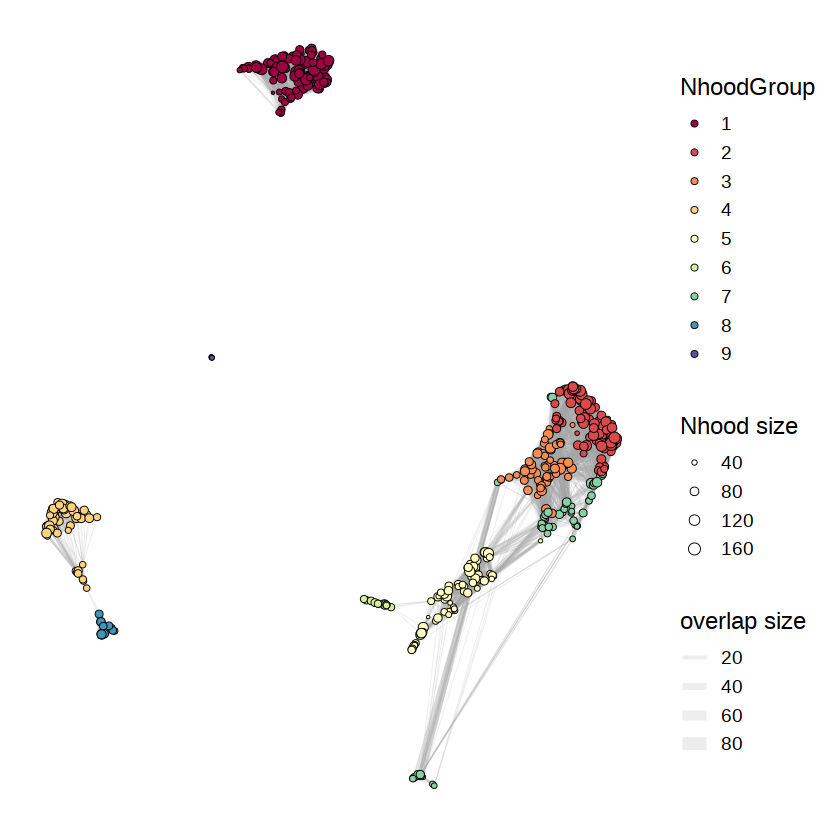

In [26]:
plotNhoodGroups(embryo_milo, da_results, layout="umap") 

Converting group.by to factor...



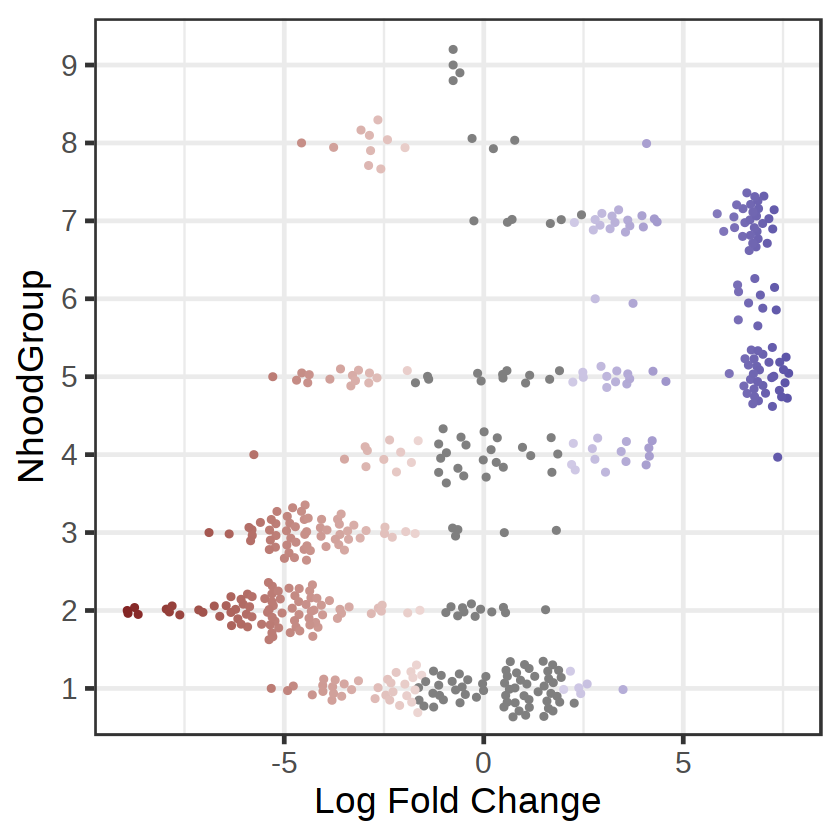

In [27]:
plotDAbeeswarm(da_results, "NhoodGroup")

Found 333 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping



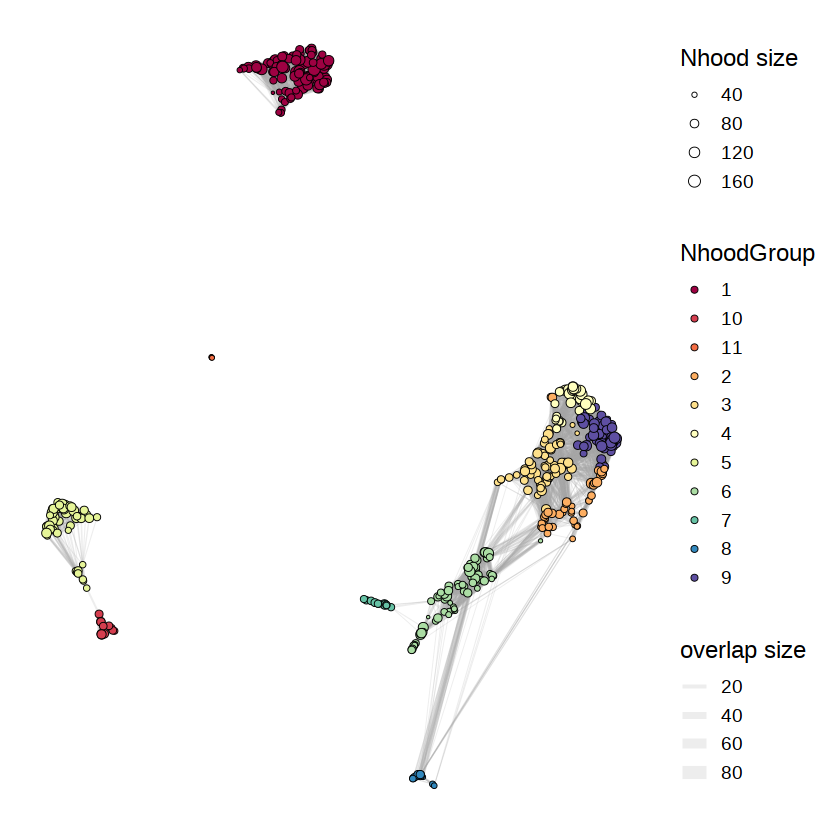

In [28]:
set.seed(42)
da_results <- groupNhoods(embryo_milo, da_results, max.lfc.delta = 5, overlap=5)
plotNhoodGroups(embryo_milo, da_results, layout="umap")

Converting group.by to factor...



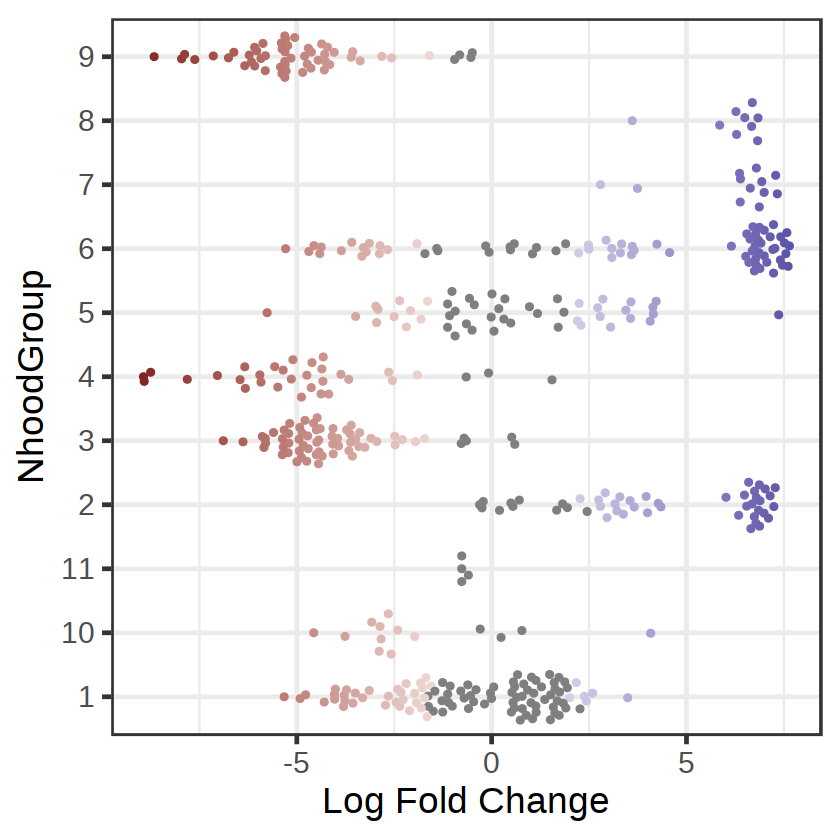

In [29]:
plotDAbeeswarm(da_results, group.by = "NhoodGroup")

In [30]:
## Exclude zero counts genes
keep.rows <- rowSums(logcounts(embryo_milo)) != 0
embryo_milo <- embryo_milo[keep.rows, ]

## Find HVGs
set.seed(101)
dec <- modelGeneVar(embryo_milo)
hvgs <- getTopHVGs(dec, n=2000)
head(hvgs)

[1] "ENSMUSG00000032083" "ENSMUSG00000095180" "ENSMUSG00000061808"
[4] "ENSMUSG00000002985" "ENSMUSG00000024990" "ENSMUSG00000024391"

In [31]:
set.seed(42)
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs, 
                                       aggregate.samples = TRUE, sample_col = "sample")

head(nhood_markers)

,logFC_1,adj.P.Val_1,logFC_2,adj.P.Val_2,logFC_3,adj.P.Val_3,logFC_4,adj.P.Val_4,logFC_5,adj.P.Val_5,⋯,adj.P.Val_7,logFC_8,adj.P.Val_8,logFC_9,adj.P.Val_9,logFC_10,adj.P.Val_10,logFC_11,adj.P.Val_11,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000027186,2.6285439,1.172600e-54,0.4573121,2.334379e-07,0.7954342,2.827504e-05,0.4782332,7.783916e-08,1.502465,1.460413e-46,⋯,1.308991e-38,0.5750015,5.365270e-14,1.8908255,0.002063781,1.1190147,3.669296e-38,3.278838,2.897031e-58,ENSMUSG00000027186
ENSMUSG00000042367,2.4494887,2.557294e-38,0.6287964,2.334379e-07,0.7349817,1.354185e-03,0.5164532,9.072353e-07,2.752881,8.507875e-45,⋯,1.483085e-37,0.7229855,1.587599e-13,1.0396398,0.003653871,1.4433328,6.375865e-22,3.940708,2.610667e-54,ENSMUSG00000042367
ENSMUSG00000073243,0.9433798,2.557294e-38,0.3824694,3.168210e-06,0.5762818,2.130219e-03,0.5336451,1.209104e-05,2.687943,1.425561e-42,⋯,3.305334e-30,1.1686016,4.097025e-13,0.3222594,0.008519428,0.8038941,1.114076e-18,3.709108,2.906466e-51,ENSMUSG00000073243
ENSMUSG00000027225,0.7469867,2.096012e-35,0.5209745,4.890324e-06,0.4715935,1.866465e-02,1.9453231,1.415936e-05,2.315829,2.501801e-39,⋯,2.339772e-29,0.6710902,2.377115e-12,0.7408876,0.012401260,0.8136437,1.966274e-18,3.181547,1.073758e-39,ENSMUSG00000027225
ENSMUSG00000006205,1.8489208,3.176184e-35,0.6156185,2.491058e-05,0.7125107,2.673176e-02,0.6806909,3.386181e-05,1.738097,3.332575e-37,⋯,7.077834e-25,0.6776552,6.725889e-12,0.2391082,0.018573877,0.9647633,1.932622e-16,4.317741,7.752577e-38,ENSMUSG00000006205
ENSMUSG00000001025,1.8751143,1.033233e-34,0.3502682,4.169857e-05,0.5731713,3.119687e-02,0.3036732,4.159045e-05,1.722407,2.695075e-35,⋯,5.143597e-20,0.6212448,6.174514e-11,0.5538477,0.018573877,0.8561389,6.965136e-15,3.246855,5.913993e-37,ENSMUSG00000001025


In [32]:
gr5_markers <- nhood_markers[c("logFC_5", "adj.P.Val_5")] 
colnames(gr5_markers) <- c("logFC", "adj.P.Val")

head(gr5_markers[order(gr5_markers$adj.P.Val), ])

,logFC,adj.P.Val
,<dbl>,<dbl>
ENSMUSG00000027186,1.502465,1.460413e-46
ENSMUSG00000042367,2.752881,8.507875e-45
ENSMUSG00000073243,2.687943,1.425561e-42
ENSMUSG00000027225,2.315829,2.501801e-39
ENSMUSG00000006205,1.738097,3.332575e-37
ENSMUSG00000001025,1.722407,2.695075e-35


In [33]:
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs, 
                                       aggregate.samples = TRUE, sample_col = "sample",
                                       subset.groups = c("5")
                                       )

Warning message in all(structure(c(1.50246477502317, 2.7528806059783, 2.6879425348665, :
“coercing argument of type 'double' to logical”


In [34]:
head(nhood_markers)

,logFC_5,adj.P.Val_5,GeneID
,<dbl>,<dbl>,<chr>
ENSMUSG00000059412,1.502465,1.460413e-46,ENSMUSG00000059412
ENSMUSG00000043501,2.752881,8.507875e-45,ENSMUSG00000043501
ENSMUSG00000031883,2.687943,1.425561e-42,ENSMUSG00000031883
ENSMUSG00000028307,2.315829,2.501801e-39,ENSMUSG00000028307
ENSMUSG00000028435,1.738097,3.332575e-37,ENSMUSG00000028435
ENSMUSG00000027690,1.722407,2.695075e-35,ENSMUSG00000027690


In [35]:
nhood_markers <- findNhoodGroupMarkers(embryo_milo, da_results, subset.row = hvgs,
                                       subset.nhoods = da_results$NhoodGroup %in% c('5','6'),
                                       aggregate.samples = TRUE, sample_col = "sample")

Warning message:
“Zero sample variances detected, have been offset away from zero”
Warning message:
“Zero sample variances detected, have been offset away from zero”


In [36]:
head(nhood_markers)

,logFC_5,adj.P.Val_5,logFC_6,adj.P.Val_6,GeneID
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000024391,5.861832,6.196019e-13,-5.861832,6.196019e-13,ENSMUSG00000024391
ENSMUSG00000032083,7.004622,6.196019e-13,-7.004622,6.196019e-13,ENSMUSG00000032083
ENSMUSG00000061808,6.916851,1.064876e-12,-6.916851,1.064876e-12,ENSMUSG00000061808
ENSMUSG00000031765,4.603518,1.535327e-12,-4.603518,1.535327e-12,ENSMUSG00000031765
ENSMUSG00000032359,4.372320,1.644610e-12,-4.372320,1.644610e-12,ENSMUSG00000032359
ENSMUSG00000021278,4.543839,2.513612e-12,-4.543839,2.513612e-12,ENSMUSG00000021278


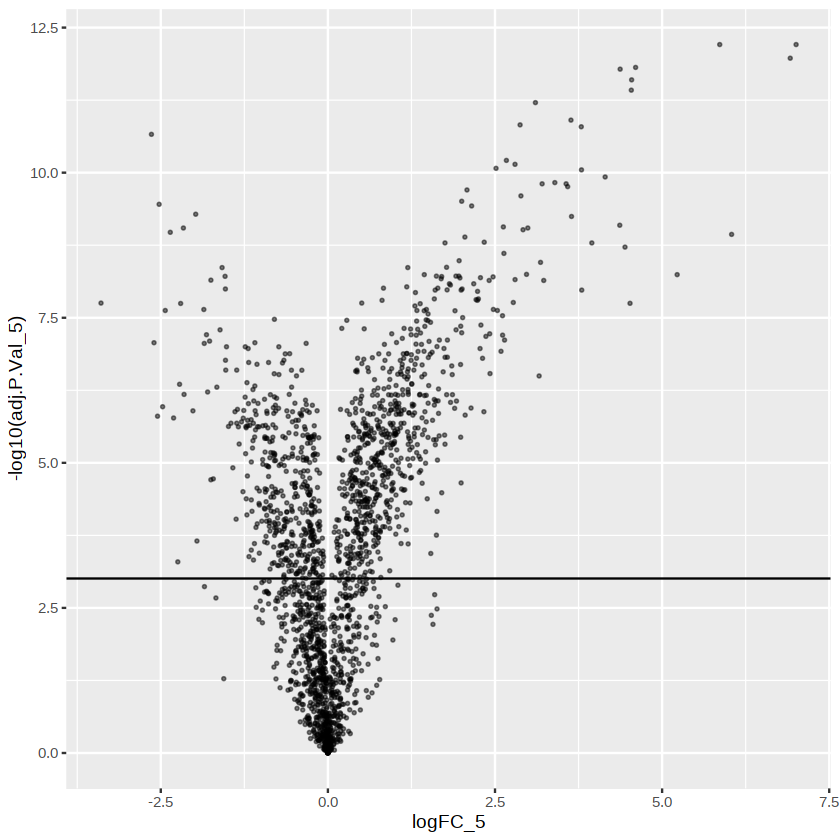

In [37]:
ggplot(nhood_markers, aes(logFC_5, -log10(adj.P.Val_5 ))) + 
  geom_point(alpha=0.5, size=0.5) +
  geom_hline(yintercept = 3)

In [38]:
markers <- rownames(nhood_markers)[nhood_markers$adj.P.Val_5 < 0.01 & nhood_markers$logFC_5 > 0]


Warning message in plotNhoodExpressionGroups(embryo_milo, da_results, features = intersect(rownames(embryo_milo), :
“Nothing in nhoodExpression(x): computing for requested features...”


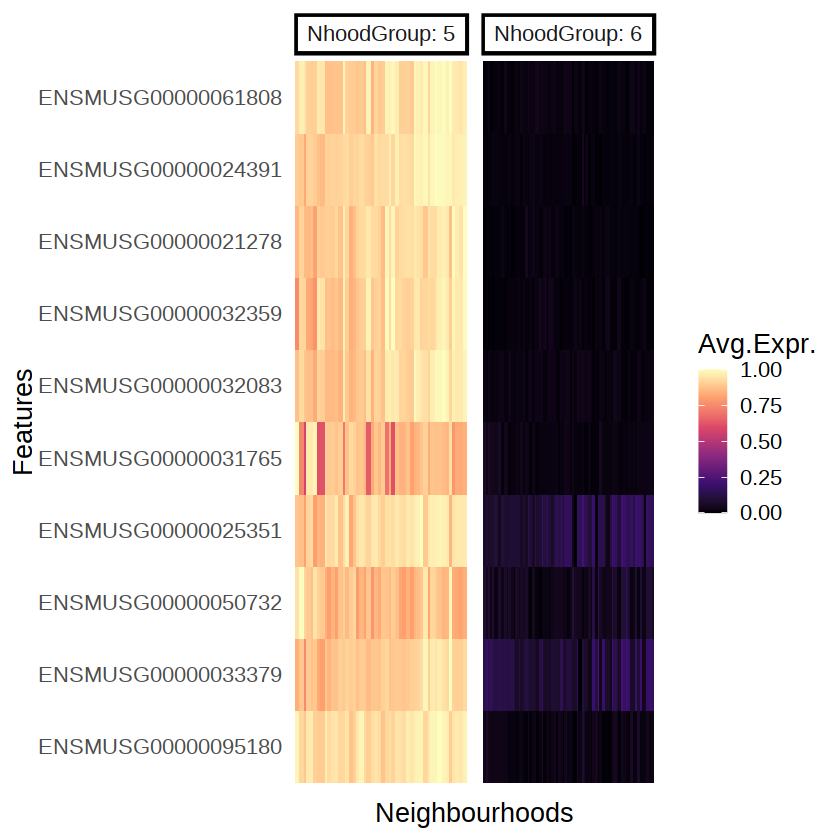

In [39]:
set.seed(42)
plotNhoodExpressionGroups(embryo_milo, da_results, features=intersect(rownames(embryo_milo), markers[1:10]),
                          subset.nhoods = da_results$NhoodGroup %in% c('6','5'), 
                          scale=TRUE,
                          grid.space = "fixed")

In [40]:
dge_6 <- testDiffExp(embryo_milo, da_results, design = ~ stage, meta.data = data.frame(colData(embryo_milo)),
                     subset.row = rownames(embryo_milo)[1:5], subset.nhoods=da_results$NhoodGroup=="6")

dge_6

Warning message in fitFDist(var, df1 = df, covariate = covariate):
“More than half of residual variances are exactly zero: eBayes unreliable”


,logFC,AveExpr,t,P.Value,adj.P.Val,B,Nhood.Group
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUSG00000025902,-0.02441640,0.02719437,-2.066917,0.03898193,0.1949097,-8.977265,6
ENSMUSG00000033845,-0.02963583,2.28381975,-0.682995,0.49475779,1.0000000,-10.877667,6
ENSMUSG00000051951,0.00000000,0.00000000,0.000000,1.00000000,1.0000000,-11.111075,6
ENSMUSG00000102343,0.00000000,0.00000000,0.000000,1.00000000,1.0000000,-11.111075,6
ENSMUSG00000025900,0.00000000,0.00000000,0.000000,1.00000000,1.0000000,-11.111075,6
